# Facebook Prophet

## 1. What is Prophet?

**Prophet** is a time-series forecasting model originally developed by **Facebook (now Meta)**.

It is designed for time series that contain:

- **Trend**
- **Seasonality**
- **Holidays / special events**
- **Changepoints**
- Missing observations
- Outliers

The main idea behind Prophet is to decompose a time series into different components.

$$
\boxed{
y(t)=g(t)+s(t)+h(t)+\epsilon_t
}
$$

where:

- $g(t)$ = Trend
- $s(t)$ = Seasonality
- $h(t)$ = Holiday / Event effects
- $\epsilon_t$ = Error / Noise

---

# 2. Why Use Prophet?

Traditional models such as ARIMA/SARIMA require concepts such as:

- Stationarity
- Differencing
- ACF
- PACF
- $(p,d,q)$
- Seasonal $(P,D,Q)$

Prophet takes a different approach.

Instead of primarily modeling autocorrelation, Prophet models the time series through its major components:

```text
                    Time Series
                         │
                         ▼
                     Prophet
                         │
          ┌──────────────┼──────────────┐
          ↓              ↓              ↓
        Trend        Seasonality     Holidays
          │              │              │
          └──────────────┼──────────────┘
                         ↓
                      Forecast

In [2]:
pip install prophet

   ---------------------------------------- 0.0/12.1 MB ? eta -:--:--
   - -------------------------------------- 0.5/12.1 MB 2.5 MB/s eta 0:00:05
   ------ --------------------------------- 1.8/12.1 MB 4.9 MB/s eta 0:00:03
   -------- ------------------------------- 2.6/12.1 MB 4.9 MB/s eta 0:00:02
   ------------ --------------------------- 3.7/12.1 MB 4.4 MB/s eta 0:00:02
   ---------------- ----------------------- 5.0/12.1 MB 4.9 MB/s eta 0:00:02
   ------------------- -------------------- 5.8/12.1 MB 4.7 MB/s eta 0:00:02
   ---------------------- ----------------- 6.8/12.1 MB 4.7 MB/s eta 0:00:02
   ------------------------- -------------- 7.6/12.1 MB 4.6 MB/s eta 0:00:01
   ------------------------- -------------- 7.9/12.1 MB 4.5 MB/s eta 0:00:01
   ------------------------- -------------- 7.9/12.1 MB 4.5 MB/s eta 0:00:01
   ------------------------- -------------- 7.9/12.1 MB 4.5 MB/s eta 0:00:01
   ------------------------------ --------- 9.2/12.1 MB 3.8 MB/s eta 0:00:01
   ---

In [5]:
pip install openpyxl


   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpy

In [1]:
from prophet import Prophet
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.seasonal import seasonal_decompose
import random

from sklearn.metrics import mean_absolute_percentage_error

In [2]:
df = pd.read_excel(f"Groceries_Sales_data.xlsx",index_col=0)
df.head()

,Sales
Date,
2018-02-01,21199.0
2018-02-02,10634.0
2018-02-03,7966.0
2018-02-04,1353.0
2018-02-05,9497.0


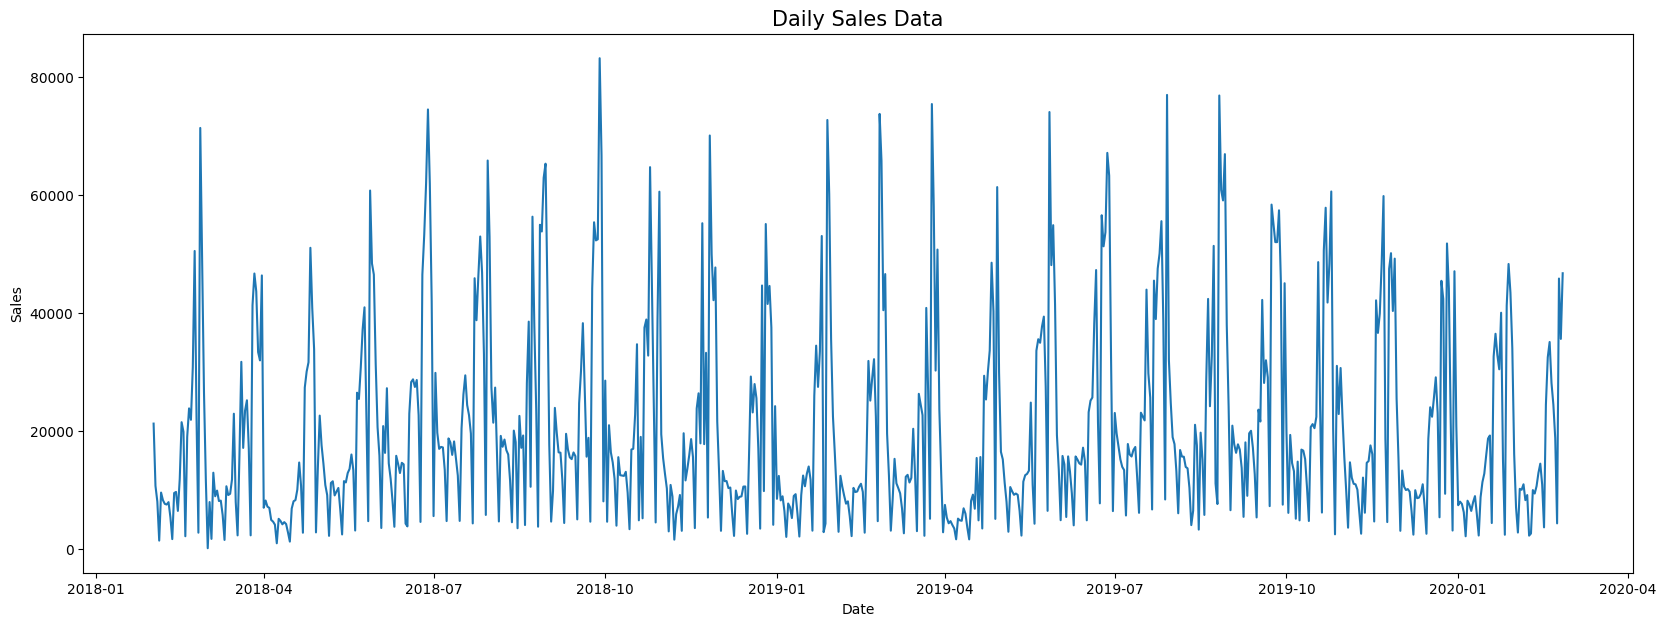

In [3]:
fig, ax = plt.subplots(figsize=(20,7))
a = sns.lineplot(x="Date", y="Sales", data=df)
a.set_title("Daily Sales Data",fontsize=15)
plt.show()

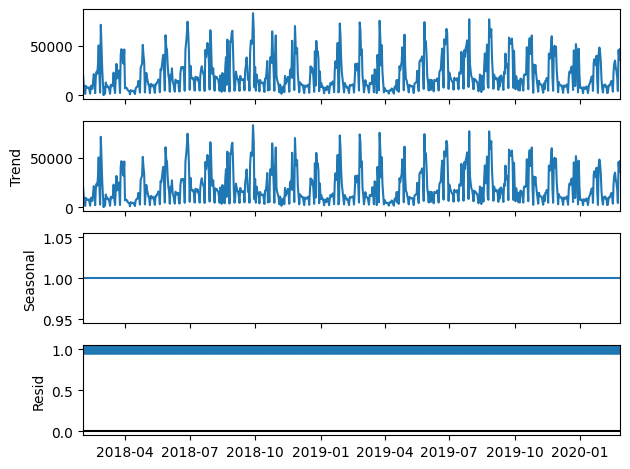

In [4]:
result_2 = seasonal_decompose(df, model='multiplicative', period=1)
result_2.plot()
plt.show()

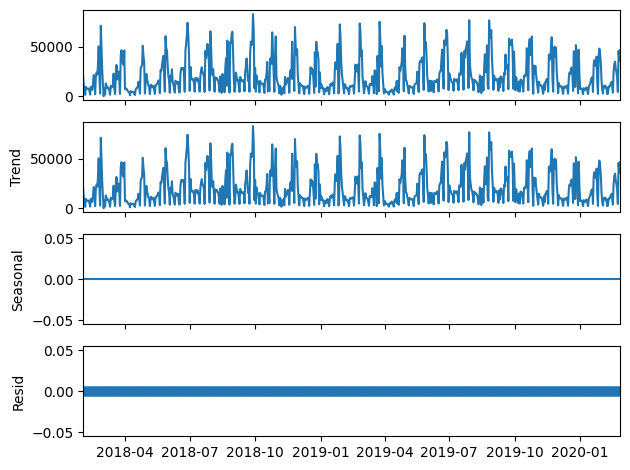

In [5]:
result_3 = seasonal_decompose(df, model='additive', period=1)
result_3.plot()
plt.show()

In [6]:
df.index = pd.to_datetime(df.index)
df

,Sales
Date,
2018-02-01,21199.0
2018-02-02,10634.0
2018-02-03,7966.0
2018-02-04,1353.0
2018-02-05,9497.0
...,...
2020-02-22,18723.1
2020-02-23,4274.9
2020-02-24,45805.7


In [7]:
y = df["Sales"]
y.name = "Sales"
seasonal_df = y.to_frame()
seasonal_df

,Sales
Date,
2018-02-01,21199.0
2018-02-02,10634.0
2018-02-03,7966.0
2018-02-04,1353.0
2018-02-05,9497.0
...,...
2020-02-22,18723.1
2020-02-23,4274.9
2020-02-24,45805.7


In [8]:
seasonal_df["trend"] = seasonal_df["Sales"].rolling(window=7, center=True).mean()
seasonal_df.head(10)

,Sales,trend
Date,,
2018-02-01,21199.0,NaN
2018-02-02,10634.0,NaN
2018-02-03,7966.0,NaN
2018-02-04,1353.0,9491.000000
2018-02-05,9497.0,7529.857143
2018-02-06,8207.0,7136.142857
2018-02-07,7581.0,6757.285714
2018-02-08,7471.0,6793.285714
2018-02-09,7878.0,6782.142857


In [9]:
seasonal_df["detrended"] = seasonal_df["Sales"] - seasonal_df["trend"]
seasonal_df.head(10)

,Sales,trend,detrended
Date,,,
2018-02-01,21199.0,NaN,NaN
2018-02-02,10634.0,NaN,NaN
2018-02-03,7966.0,NaN,NaN
2018-02-04,1353.0,9491.000000,-8138.000000
2018-02-05,9497.0,7529.857143,1967.142857
2018-02-06,8207.0,7136.142857,1070.857143
2018-02-07,7581.0,6757.285714,823.714286
2018-02-08,7471.0,6793.285714,677.714286
2018-02-09,7878.0,6782.142857,1095.857143


In [10]:
seasonal_df.index = pd.to_datetime(seasonal_df.index)
seasonal_df["month"] = seasonal_df.index.month
seasonal_df["seasonality"] = seasonal_df.groupby("month")["detrended"].transform("mean")
seasonal_df.head(15)

,Sales,trend,detrended,month,seasonality
Date,,,,,
2018-02-01,21199.0,NaN,NaN,2,-112.66203
2018-02-02,10634.0,NaN,NaN,2,-112.66203
2018-02-03,7966.0,NaN,NaN,2,-112.66203
2018-02-04,1353.0,9491.000000,-8138.000000,2,-112.66203
2018-02-05,9497.0,7529.857143,1967.142857,2,-112.66203
2018-02-06,8207.0,7136.142857,1070.857143,2,-112.66203
2018-02-07,7581.0,6757.285714,823.714286,2,-112.66203
2018-02-08,7471.0,6793.285714,677.714286,2,-112.66203
2018-02-09,7878.0,6782.142857,1095.857143,2,-112.66203


In [11]:
seasonal_df = y.to_frame()

# calculate the trend component
seasonal_df["trend"] = seasonal_df["Sales"].rolling(window=13, center=True).mean()

# detrend the series
seasonal_df["detrended"] = seasonal_df["Sales"] - seasonal_df["trend"]

# calculate the seasonal component
seasonal_df.index = pd.to_datetime(seasonal_df.index)
seasonal_df["month"] = seasonal_df.index.month
seasonal_df["seasonality"] = seasonal_df.groupby("month")["detrended"].transform("mean")

# get the residuals
seasonal_df["resid"] = seasonal_df["detrended"] - seasonal_df["seasonality"]

# display the DF
seasonal_df.head(15)

,Sales,trend,detrended,month,seasonality,resid
Date,,,,,,
2018-02-01,21199.0,NaN,NaN,2,381.152198,NaN
2018-02-02,10634.0,NaN,NaN,2,381.152198,NaN
2018-02-03,7966.0,NaN,NaN,2,381.152198,NaN
2018-02-04,1353.0,NaN,NaN,2,381.152198,NaN
2018-02-05,9497.0,NaN,NaN,2,381.152198,NaN
2018-02-06,8207.0,NaN,NaN,2,381.152198,NaN
2018-02-07,7581.0,8287.230769,-706.230769,2,381.152198,-1087.382967
2018-02-08,7471.0,7147.930769,323.069231,2,381.152198,-58.082967
2018-02-09,7878.0,7237.546154,640.453846,2,381.152198,259.301648


array([<Axes: xlabel='Date'>, <Axes: xlabel='Date'>,
       <Axes: xlabel='Date'>, <Axes: xlabel='Date'>], dtype=object)

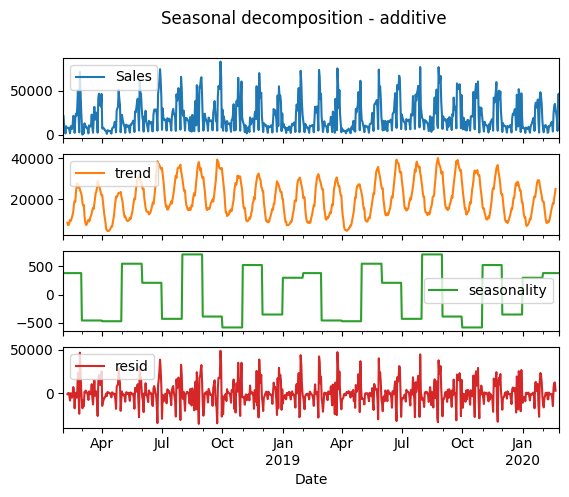

In [12]:
seasonal_df.loc[:, ["Sales", "trend", "seasonality", "resid"]].plot(subplots=True, title="Seasonal decomposition - additive")

In [13]:
df=df.reset_index(['Date'])
df

,Date,Sales
0,2018-02-01,21199.0
1,2018-02-02,10634.0
2,2018-02-03,7966.0
3,2018-02-04,1353.0
4,2018-02-05,9497.0
...,...,...
751,2020-02-22,18723.1
752,2020-02-23,4274.9
753,2020-02-24,45805.7
754,2020-02-25,35566.3


In [15]:
# Extract features
df_copy = df.copy()

df_copy['date'] = df['Date']
df_copy['month'] = df_copy['date'].dt.strftime('%B')
df_copy['year'] = df_copy['date'].dt.strftime('%Y')
df_copy['dayofweek'] = df_copy['date'].dt.strftime('%A')
df_copy['quarter'] = df_copy['date'].dt.quarter
df_copy['dayofyear'] = df_copy['date'].dt.dayofyear
df_copy['dayofmonth'] = df_copy['date'].dt.day
df_copy['weekofyear'] = df_copy['date'].dt.isocalendar().week
df_copy.head()

,Date,Sales,date,month,year,dayofweek,quarter,dayofyear,dayofmonth,weekofyear
0,2018-02-01,21199.0,2018-02-01,February,2018,Thursday,1,32,1,5
1,2018-02-02,10634.0,2018-02-02,February,2018,Friday,1,33,2,5
2,2018-02-03,7966.0,2018-02-03,February,2018,Saturday,1,34,3,5
3,2018-02-04,1353.0,2018-02-04,February,2018,Sunday,1,35,4,5
4,2018-02-05,9497.0,2018-02-05,February,2018,Monday,1,36,5,6


In [16]:
X = df_copy[['dayofweek','quarter','month','year',
           'dayofyear','dayofmonth','weekofyear']]
y = df['Sales']

In [17]:
df_new = pd.concat([X, y], axis=1)
df_new.head()

,dayofweek,quarter,month,year,dayofyear,dayofmonth,weekofyear,Sales
0,Thursday,1,February,2018,32,1,5,21199.0
1,Friday,1,February,2018,33,2,5,10634.0
2,Saturday,1,February,2018,34,3,5,7966.0
3,Sunday,1,February,2018,35,4,5,1353.0
4,Monday,1,February,2018,36,5,6,9497.0


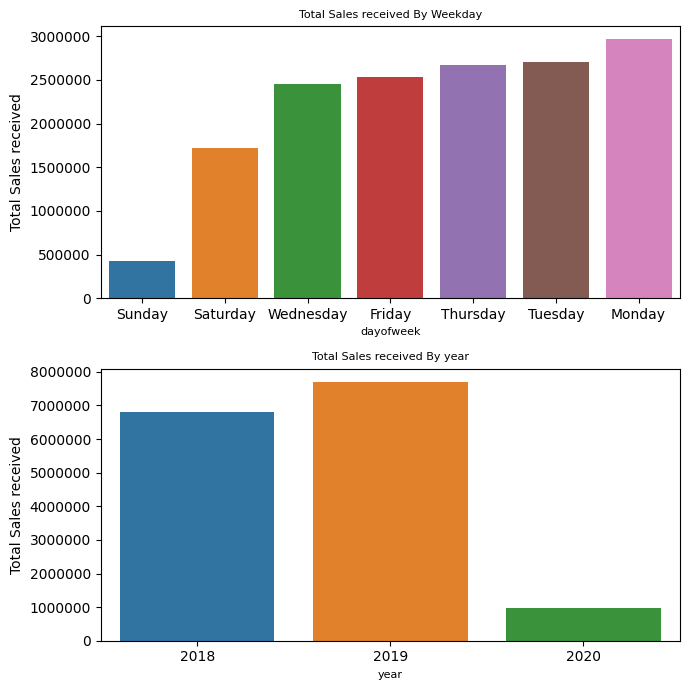

In [19]:
# fig,(ax1,ax2,ax3,ax4)= plt.subplots(nrows=4)
fig,(ax1,ax2)= plt.subplots(nrows=2)
fig.set_size_inches(7,7)

week_day_Aggregated = pd.DataFrame(df_new.groupby("dayofweek")["Sales"].sum()).reset_index().sort_values('Sales')
sns.barplot(data=week_day_Aggregated,x="dayofweek",y="Sales",hue = 'dayofweek',ax=ax1,dodge=False)
ax1.set(xlabel='dayofweek', ylabel='Total Sales received')
ax1.xaxis.label.set_size(8)
ax1.set_title("Total Sales received By Weekday",fontsize=8)
ax1.ticklabel_format(style='plain',axis='y')


yearAggregated = pd.DataFrame(df_new.groupby("year")["Sales"].sum()).reset_index()
sns.barplot(data=yearAggregated,x="year",y="Sales",hue='year',ax=ax2)
ax2.set(xlabel='year', ylabel='Total Sales received')
ax2.xaxis.label.set_size(8)
ax2.set_title("Total Sales received By year",fontsize=8)
ax2.ticklabel_format(style='plain',axis='y')

fig.tight_layout()

In [21]:
df=df.rename(columns={'Date':'ds','Sales':'y'})
df.tail()

,ds,y
751,2020-02-22,18723.1
752,2020-02-23,4274.9
753,2020-02-24,45805.7
754,2020-02-25,35566.3
755,2020-02-26,46703.0


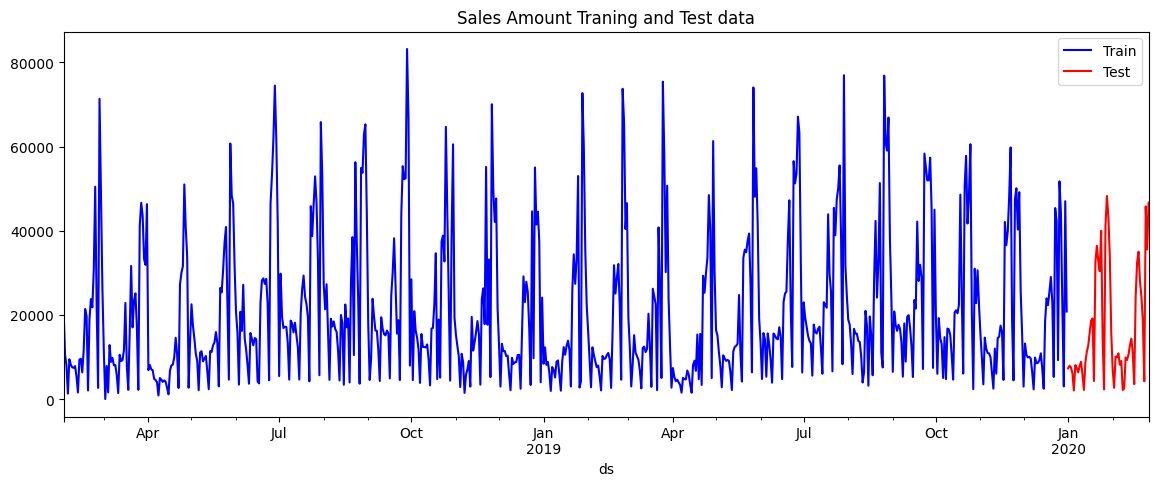

In [22]:
end_date = '2019-12-31'
X_tr = df.loc[df['ds'] <= end_date]
X_tst = df.loc[df['ds'] > end_date]

pd.plotting.register_matplotlib_converters()
f, ax = plt.subplots(figsize=(14,5))
X_tr.plot(kind='line', x='ds', y='y', color='blue', label='Train', ax=ax)
X_tst.plot(kind='line', x='ds', y='y', color='red', label='Test', ax=ax)
plt.title('Sales Amount Traning and Test data')
plt.show()

In [23]:
# Modelling
model =Prophet()
model.fit(X_tr)

14:10:06 - cmdstanpy - INFO - Chain [1] start processing
14:10:07 - cmdstanpy - INFO - Chain [1] done processing


In [24]:
future = model.make_future_dataframe(periods=57, freq='D')
forecast = model.predict(future)
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].head()

,ds,yhat,yhat_lower,yhat_upper
0,2018-02-01,22910.616792,4357.270196,41246.358433
1,2018-02-02,21601.960285,1298.615740,39120.327266
2,2018-02-03,14070.248884,-7106.469956,32986.272775
3,2018-02-04,1665.279492,-16094.920856,21991.642848
4,2018-02-05,25526.739943,5826.002310,44994.334927


###  make_future_dataframe by default also includes the historical dates

yhat_lower	Lower bound of prediction interval
yhat_upper	Upper bound of prediction interval

In [27]:
future_2 = model.make_future_dataframe(periods=60)
forecast_2 = model.predict(future_2)
forecast_2[['ds', 'yhat']].tail(5)

,ds,yhat
754,2020-02-25,27921.524682
755,2020-02-26,25523.001943
756,2020-02-27,28090.570315
757,2020-02-28,26781.912207
758,2020-02-29,19250.199205


In [29]:
X_tst_forecast = model.predict(X_tst)
X_tst_forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(7)

,ds,yhat,yhat_lower,yhat_upper
50,2020-02-20,28042.610141,10284.810533,47556.081578
51,2020-02-21,26733.952033,7218.129560,45221.173979
52,2020-02-22,19202.239031,-1087.444176,38671.094882
53,2020-02-23,6797.268037,-12262.319194,25203.345958
54,2020-02-24,30658.726886,12827.025301,49152.679643
55,2020-02-25,27921.524682,8648.503269,46257.737152
56,2020-02-26,25523.001943,6510.566174,44136.529127


In [30]:
X_tst_forecast

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2020-01-01,23191.061935,7782.123515,44730.819790,23191.061935,23191.061935,1948.258618,1948.258618,1948.258618,1948.258618,1948.258618,1948.258618,0.0,0.0,0.0,25139.320554
1,2020-01-02,23197.913389,9362.986963,48544.186731,23197.913389,23197.913389,4508.975537,4508.975537,4508.975537,4508.975537,4508.975537,4508.975537,0.0,0.0,0.0,27706.888925
2,2020-01-03,23204.764842,7416.703454,45521.755663,23204.764842,23204.764842,3193.465975,3193.465975,3193.465975,3193.465975,3193.465975,3193.465975,0.0,0.0,0.0,26398.230817
3,2020-01-04,23211.616295,-704.870260,38168.608396,23211.616295,23211.616295,-4345.098481,-4345.098481,-4345.098481,-4345.098481,-4345.098481,-4345.098481,0.0,0.0,0.0,18866.517815
4,2020-01-05,23218.467749,-12262.644422,26764.721215,23218.467749,23218.467749,-16756.920928,-16756.920928,-16756.920928,-16756.920928,-16756.920928,-16756.920928,0.0,0.0,0.0,6461.546821
5,2020-01-06,23225.319202,10237.853780,50020.486723,23225.319202,23225.319202,7097.686468,7097.686468,7097.686468,7097.686468,7097.686468,7097.686468,0.0,0.0,0.0,30323.005670
6,2020-01-07,23232.170656,7422.911992,46631.367267,23232.170651,23232.170669,4353.632811,4353.632811,4353.632811,4353.632811,4353.632811,4353.632811,0.0,0.0,0.0,27585.803466
7,2020-01-08,23239.022109,6436.858281,44862.691085,23239.022077,23239.022144,1948.258618,1948.258618,1948.258618,1948.258618,1948.258618,1948.258618,0.0,0.0,0.0,25187.280727
8,2020-01-09,23245.873562,8531.938527,47513.629146,23245.873510,23245.873612,4508.975537,4508.975537,4508.975537,4508.975537,4508.975537,4508.975537,0.0,0.0,0.0,27754.849099
9,2020-01-10,23252.725016,7058.638896,46156.154532,23252.724930,23252.725098,3193.465975,3193.465975,3193.465975,3193.465975,3193.465975,3193.465975,0.0,0.0,0.0,26446.190991


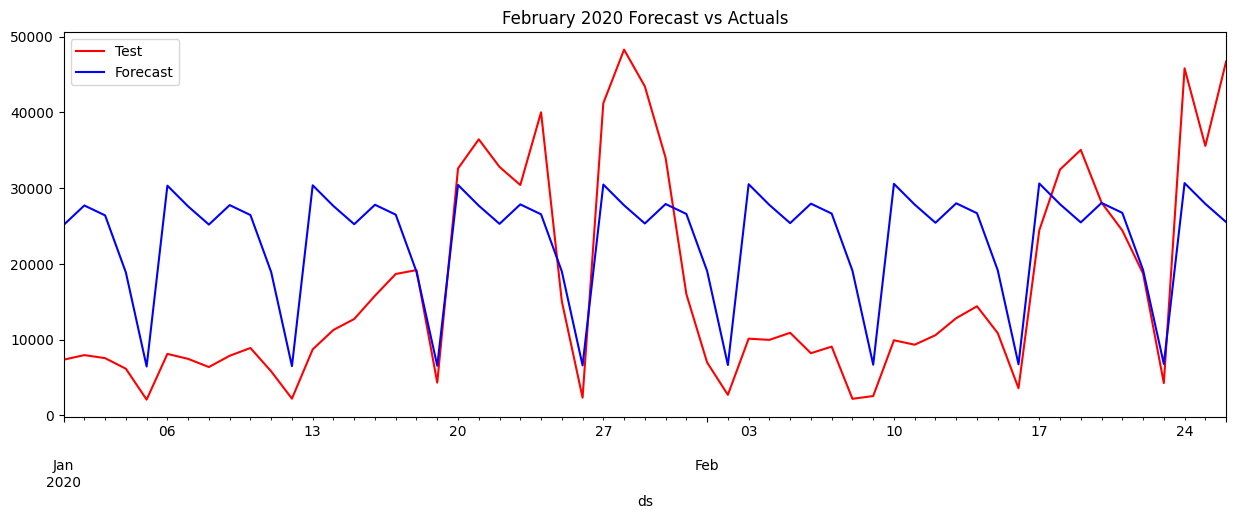

In [31]:
f, ax = plt.subplots(figsize=(14,5))
f.set_figheight(5)
f.set_figwidth(15)
X_tst.plot(kind='line',x='ds', y='y', color='red', label='Test', ax=ax)
X_tst_forecast.plot(kind='line',x='ds',y='yhat', color='blue',label='Forecast', ax=ax)
plt.title('February 2020 Forecast vs Actuals')
plt.show()

In [32]:
mape = mean_absolute_percentage_error(X_tst['y'],X_tst_forecast['yhat'])
print("MAPE",mape)

MAPE 1.2930056774613838


In [66]:
import holidays
india_holidays = holidays.India(years = 2018)

holiday_india_df = pd.DataFrame([])

for date, name in sorted(india_holidays.items()):
    print(date, name) 
    holiday_india_df = pd.concat([holiday_india_df, pd.DataFrame({'ds': date, 'holiday': name}, index=[0])], ignore_index=True)

2018-01-26 Republic Day
2018-02-13 Maha Shivaratri
2018-03-02 Holi
2018-03-29 Mahavir Jayanti
2018-03-30 Good Friday
2018-04-14 Dr. B. R. Ambedkar's Jayanti
2018-04-30 Buddha Purnima
2018-06-16 Id-ul-Fitr
2018-08-15 Independence Day
2018-08-22 Id-ul-Zuha (Bakrid)
2018-09-03 Janmashtami (Vaishnava)
2018-09-21 Muharram
2018-10-02 Mahatma Gandhi's Jayanti
2018-10-19 Dussehra
2018-11-07 Diwali (Deepavali)
2018-11-21 Milad-un-Nabi
2018-11-23 Guru Nanak's Jayanti
2018-12-25 Christmas


In [67]:
holiday_india_df

,ds,holiday
0,2018-01-26,Republic Day
1,2018-02-13,Maha Shivaratri
2,2018-03-02,Holi
3,2018-03-29,Mahavir Jayanti
4,2018-03-30,Good Friday
5,2018-04-14,Dr. B. R. Ambedkar's Jayanti
6,2018-04-30,Buddha Purnima
7,2018-06-16,Id-ul-Fitr
8,2018-08-15,Independence Day
9,2018-08-22,Id-ul-Zuha (Bakrid)


In [68]:
india_holidays_mh = holidays.India(years = 2018,subdiv='MH')

holiday_india_mh = pd.DataFrame([])

for date, name in sorted(india_holidays_mh.items()):
    print(date, name) 
    holiday_india_mh = pd.concat([holiday_india_mh, pd.DataFrame({'ds': date, 'holiday': name}, index=[0])], ignore_index=True)

2018-01-26 Republic Day
2018-02-13 Maha Shivaratri
2018-02-19 Chhatrapati Shivaji Maharaj Jayanti
2018-03-02 Holi
2018-03-18 Gudi Padwa
2018-03-29 Mahavir Jayanti
2018-03-30 Good Friday
2018-04-14 Dr. B. R. Ambedkar's Jayanti
2018-04-30 Buddha Purnima
2018-05-01 Maharashtra Day
2018-06-16 Id-ul-Fitr
2018-08-15 Independence Day
2018-08-17 Parsi New Year (Shahenshahi)
2018-08-22 Id-ul-Zuha (Bakrid)
2018-09-03 Janmashtami (Vaishnava)
2018-09-21 Muharram
2018-10-02 Mahatma Gandhi's Jayanti
2018-10-19 Dussehra
2018-11-07 Diwali (Deepavali)
2018-11-21 Milad-un-Nabi
2018-11-23 Guru Nanak's Jayanti
2018-12-25 Christmas


In [69]:
holiday_india_mh

,ds,holiday
0,2018-01-26,Republic Day
1,2018-02-13,Maha Shivaratri
2,2018-02-19,Chhatrapati Shivaji Maharaj Jayanti
3,2018-03-02,Holi
4,2018-03-18,Gudi Padwa
5,2018-03-29,Mahavir Jayanti
6,2018-03-30,Good Friday
7,2018-04-14,Dr. B. R. Ambedkar's Jayanti
8,2018-04-30,Buddha Purnima
9,2018-05-01,Maharashtra Day


In [70]:
holiday = pd.DataFrame([])
for date, name in sorted(holidays.UnitedStates(years=[2018,2019,2020]).items()):
    holiday = pd.concat([holiday, pd.DataFrame({'ds': date, 'holiday': "US-Holidays"}, index=[0])], ignore_index=True)

holiday['ds'] = pd.to_datetime(holiday['ds'])
holiday

,ds,holiday
0,2018-01-01,US-Holidays
1,2018-01-15,US-Holidays
2,2018-02-19,US-Holidays
3,2018-05-28,US-Holidays
4,2018-07-04,US-Holidays
5,2018-09-03,US-Holidays
6,2018-10-08,US-Holidays
7,2018-11-11,US-Holidays
8,2018-11-12,US-Holidays
9,2018-11-22,US-Holidays


In [71]:
holiday_2 = pd.DataFrame([])
for date, name in sorted(holidays.India(years=[2018,2019,2020]).items()):
    holiday_2 = pd.concat([holiday_2, pd.DataFrame({'ds': date, 'holiday': "IN-Holidays"}, index=[0])], ignore_index=True)

holiday_2['ds'] = pd.to_datetime(holiday_2['ds'])
holiday_2

,ds,holiday
0,2018-01-26,IN-Holidays
1,2018-02-13,IN-Holidays
2,2018-03-02,IN-Holidays
3,2018-03-29,IN-Holidays
4,2018-03-30,IN-Holidays
5,2018-04-14,IN-Holidays
6,2018-04-30,IN-Holidays
7,2018-06-16,IN-Holidays
8,2018-08-15,IN-Holidays
9,2018-08-22,IN-Holidays


### Using Prophet's built-in Indian holidays

In [47]:
m_2 = Prophet()
m_2.add_country_holidays(country_name='IN')
m_2.fit(df)

d:\anaconda\Lib\site-packages\prophet\make_holidays.py:49: UserWarning: Requested Holidays are available only from 2001 to 2035.
  return set(country_holidays(language="en_US", years=np.arange(1995, 2045)).values())
15:43:48 - cmdstanpy - INFO - Chain [1] start processing
15:43:48 - cmdstanpy - INFO - Chain [1] done processing


In [48]:
m_2.train_holiday_names

0                      Republic Day
1     Dr. B. R. Ambedkar's Birthday
2                  Independence Day
3         Mahatma Gandhi's Birthday
4                   Maha Shivaratri
5                              Holi
6               Mahavira's Birthday
7                    Buddha Purnima
8           Janmashtami (Vaishnava)
9                          Dussehra
10               Diwali (Deepavali)
11            Guru Nanak's Birthday
12                           Ashura
13               Prophet's Birthday
14                      Eid al-Fitr
15                      Eid al-Adha
16                      Good Friday
17                        Christmas
18                       Ram Navami
dtype: str

### Using your own holiday DataFrame

In [72]:
model_with_holidays = Prophet(holidays=holiday_2)
model_with_holidays.fit(X_tr)

16:42:03 - cmdstanpy - INFO - Chain [1] start processing
16:42:03 - cmdstanpy - INFO - Chain [1] done processing


In [50]:
future_holiday = model_with_holidays.make_future_dataframe(periods=57, freq='D')
forecast_holiday = model_with_holidays.predict(future_holiday)
forecast_holiday[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(7)

,ds,yhat,yhat_lower,yhat_upper
749,2020-02-20,28586.549142,10111.549045,49669.691008
750,2020-02-21,27712.241480,9968.670219,44861.997013
751,2020-02-22,20205.674871,3049.429459,39845.543495
752,2020-02-23,7412.218395,-12224.030570,26740.383873
753,2020-02-24,31339.100872,11433.811709,49607.935913
754,2020-02-25,28897.735019,9450.057895,48398.460685
755,2020-02-26,26805.952937,7426.742494,45836.449750


In [51]:
X_tst_forecast_holiday = model_with_holidays.predict(X_tst)
X_tst_forecast_holiday[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(7)

,ds,yhat,yhat_lower,yhat_upper
50,2020-02-20,28586.549142,10841.454663,46773.586888
51,2020-02-21,27712.241480,8485.373123,47658.185721
52,2020-02-22,20205.674871,-632.438619,39853.099599
53,2020-02-23,7412.218395,-11131.009988,26984.119765
54,2020-02-24,31339.100872,13514.314548,49536.296014
55,2020-02-25,28897.735019,10058.040895,47216.959455
56,2020-02-26,26805.952937,7953.191745,45556.789694


Prophet's prediction is approximately:

yhat
	​
=Trend+Seasonality+Holiday Effects+Regressor Effects

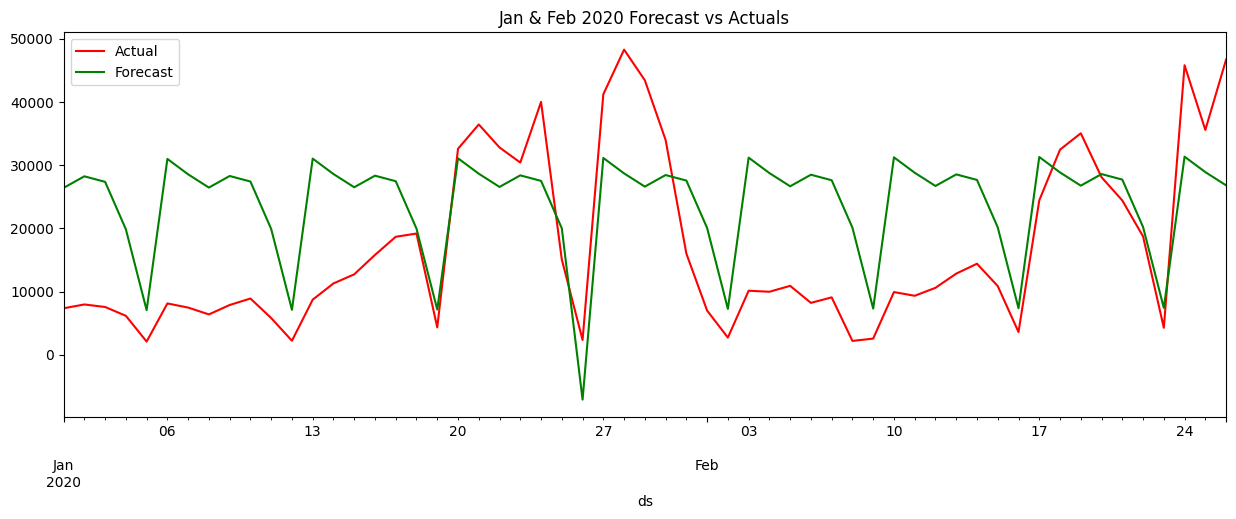

In [53]:
f, ax = plt.subplots(figsize=(14,5))
f.set_figheight(5)
f.set_figwidth(15)
X_tst.plot(kind='line',x='ds', y='y', color='red', label='Actual', ax=ax)
X_tst_forecast_holiday.plot(kind='line',x='ds',y='yhat', color='green',label='Forecast', ax=ax)
plt.title('Jan & Feb 2020 Forecast vs Actuals')
plt.show()

In [54]:
mape_holiday = mean_absolute_percentage_error(X_tst['y'],X_tst_forecast_holiday['yhat'])
print("MAPE",round(mape_holiday,4))

MAPE 1.4122


In [55]:
# Hyperparameter tunning

# n_changepoints is the number of change happen in the data. Prophet model detects them by its own. By default, its value is 25, which are uniformly placed in the first 80% of the time series. Changing n_changepoints can add value to the model.

# changepoint_prior_scale to indicate how flexible the changepoints are allowed to be. In other words, how much can the changepoints fit to the data. If you make it high it will be more flexible, but you can end up overfitting. By default, this parameter is set to 0.05

# seasonality_mode There are 2 types model seasonality mode. Additive & multiplicaticative. By default Prophet fits additive seasonalities, meaning the effect of the seasonality is added to the trend to get the forecast. Prophet can model multiplicative seasonality by setting seasonality_mode='multiplicative' in the model.

# holiday_prior_scale just like changepoint_prior_scale, holiday_prior_scale is used to smoothning the effect of holidays. By default its value is 10, which provides very little regularization. Reducing this parameter dampens holiday effects

# Seasonalities with fourier_order Prophet model, by default finds the seasonalities and adds the default parameters of the seasonality. We can modify the seasonalities effect by adding custom seasonalities as add_seasonality in the model with different fourier order.Yy default Prophet uses a Fourier order of 3 for weekly seasonality and 10 for yearly seasonality.
# seasonality_weekly / seasonality_weekly = True / Flag to add weekly seasonality. By default, Prophet adds weekly seasonality with a Fourier order of 3. If you want to disable it, you can set seasonality_weekly=False. You can also add your own weekly seasonality with a different Fourier order by using add_seasonality.

In [56]:
from sklearn.model_selection import ParameterGrid
params_grid = {'seasonality_mode':('multiplicative','additive'),
               'changepoint_prior_scale':[0.1,0.2,0.3],
              'holidays_prior_scale':[0.1,0.2,0.3],
              'n_changepoints' : [100,150]}
grid = ParameterGrid(params_grid)
cnt = 0
for p in grid:
    cnt = cnt+1

print('Total Possible Models',cnt)

Total Possible Models 36


In [81]:
strt='2019-12-31'
end='2020-02-26'
model_parameters = pd.DataFrame(columns = ['MAPE','Parameters'])
for p in grid:
    test = pd.DataFrame()
    print(p)
    random.seed(0)
    train_model =Prophet(changepoint_prior_scale = p['changepoint_prior_scale'],
                         holidays_prior_scale = p['holidays_prior_scale'],
                         n_changepoints = p['n_changepoints'],
                         seasonality_mode = p['seasonality_mode'],
                         weekly_seasonality=True,
                         daily_seasonality = True,
                         yearly_seasonality = True,
                         holidays=holiday, 
                         interval_width=0.95)
    train_model.add_country_holidays(country_name='US')
    train_model.fit(X_tr)
    train_forecast = train_model.make_future_dataframe(periods=57, freq='D',include_history = False)
    train_forecast = train_model.predict(train_forecast)
    test=train_forecast[['ds','yhat']]
    Actual = df[(df['ds']>strt) & (df['ds']<=end)]
    MAPE = mean_absolute_percentage_error(Actual['y'],abs(test['yhat']))
    print('Mean Absolute Percentage Error(MAPE)------------------------------------',MAPE)
    model_parameters.loc[len(model_parameters)] = {
        'MAPE': MAPE,
        'Parameters': p
    }

17:29:02 - cmdstanpy - INFO - Chain [1] start processing


{'changepoint_prior_scale': 0.1, 'holidays_prior_scale': 0.1, 'n_changepoints': 100, 'seasonality_mode': 'multiplicative'}


17:29:02 - cmdstanpy - INFO - Chain [1] done processing
17:29:02 - cmdstanpy - INFO - Chain [1] start processing


Mean Absolute Percentage Error(MAPE)------------------------------------ 1.0489606083607925
{'changepoint_prior_scale': 0.1, 'holidays_prior_scale': 0.1, 'n_changepoints': 100, 'seasonality_mode': 'additive'}


17:29:02 - cmdstanpy - INFO - Chain [1] done processing
17:29:02 - cmdstanpy - INFO - Chain [1] start processing


...

Mean Absolute Percentage Error(MAPE)------------------------------------ 1.083565764532771
{'changepoint_prior_scale': 0.3, 'holidays_prior_scale': 0.3, 'n_changepoints': 150, 'seasonality_mode': 'multiplicative'}


17:29:14 - cmdstanpy - INFO - Chain [1] done processing
17:29:15 - cmdstanpy - INFO - Chain [1] start processing


Mean Absolute Percentage Error(MAPE)------------------------------------ 1.0371139391402004
{'changepoint_prior_scale': 0.3, 'holidays_prior_scale': 0.3, 'n_changepoints': 150, 'seasonality_mode': 'additive'}


17:29:15 - cmdstanpy - INFO - Chain [1] done processing


Mean Absolute Percentage Error(MAPE)------------------------------------ 1.0340898319397451


In [82]:
parameters = model_parameters.sort_values(by=['MAPE'])
parameters = parameters.reset_index(drop=True)
parameters.head()

,MAPE,Parameters
0,1.004573,"{'changepoint_prior_scale': 0.3, 'holidays_pri..."
1,1.007479,"{'changepoint_prior_scale': 0.2, 'holidays_pri..."
2,1.023383,"{'changepoint_prior_scale': 0.2, 'holidays_pri..."
3,1.024131,"{'changepoint_prior_scale': 0.1, 'holidays_pri..."
4,1.027164,"{'changepoint_prior_scale': 0.3, 'holidays_pri..."


In [83]:
parameters['Parameters'][0]

{'changepoint_prior_scale': 0.3,
 'holidays_prior_scale': 0.2,
 'n_changepoints': 150,
 'seasonality_mode': 'multiplicative'}

In [84]:
# Taking best params
 
final_model = Prophet(holidays=holiday,
                      changepoint_prior_scale= 0.1,
                      holidays_prior_scale = 0.2,
                      n_changepoints = 100,
                      seasonality_mode = 'multiplicative',
                      weekly_seasonality=True,
                      daily_seasonality = True,
                      yearly_seasonality = True,
                      interval_width=0.95)
final_model.add_country_holidays(country_name='US')
final_model.fit(X_tr)

17:30:07 - cmdstanpy - INFO - Chain [1] start processing
17:30:07 - cmdstanpy - INFO - Chain [1] done processing


In [85]:
future = final_model.make_future_dataframe(periods=122, freq='D')
forecast = final_model.predict(future)
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(7)

,ds,yhat,yhat_lower,yhat_upper
814,2020-04-25,11601.428670,-14527.317690,39139.107478
815,2020-04-26,-1594.240531,-30019.388436,26245.139635
816,2020-04-27,25377.189626,-1448.459437,53621.129674
817,2020-04-28,22640.247102,-4673.825419,49640.860401
818,2020-04-29,20420.571277,-7668.455440,47702.763903
819,2020-04-30,23075.111764,-6174.281723,50592.198711
820,2020-05-01,22347.000978,-8071.682776,49050.391498


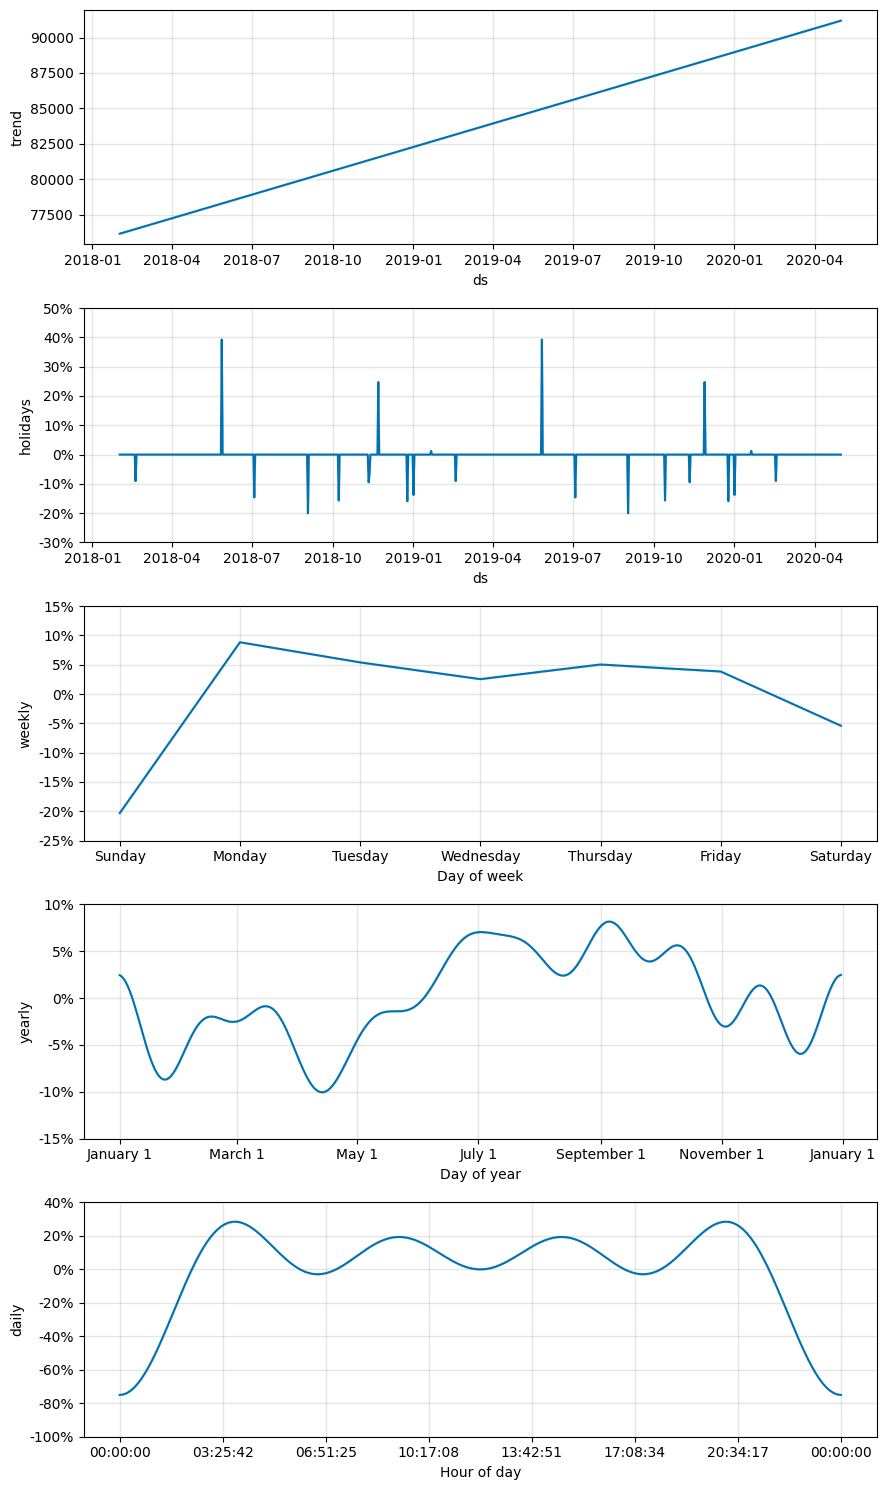

In [86]:
fig =final_model.plot_components(forecast)

In [87]:
from prophet.plot import plot_plotly, plot_components_plotly
plot_components_plotly(final_model,forecast)

d:\anaconda\Lib\site-packages\plotly\io\_json.py:558: UserWarning: Discarding nonzero nanoseconds in conversion.
  obj = obj.to_pydatetime()


In [88]:
X_tst_final= final_model.predict(X_tst)
X_tst_final[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(7)

,ds,yhat,yhat_lower,yhat_upper
50,2020-02-20,25134.729710,-2920.110772,52948.340330
51,2020-02-21,23999.905510,-3070.324670,50628.599023
52,2020-02-22,15605.640315,-11000.207477,43683.129688
53,2020-02-23,2119.419730,-27150.083537,31754.525902
54,2020-02-24,28294.369685,1930.318537,57301.051366
55,2020-02-25,25149.205398,-1962.646352,54235.562138
56,2020-02-26,22535.002575,-4828.493925,49253.313590


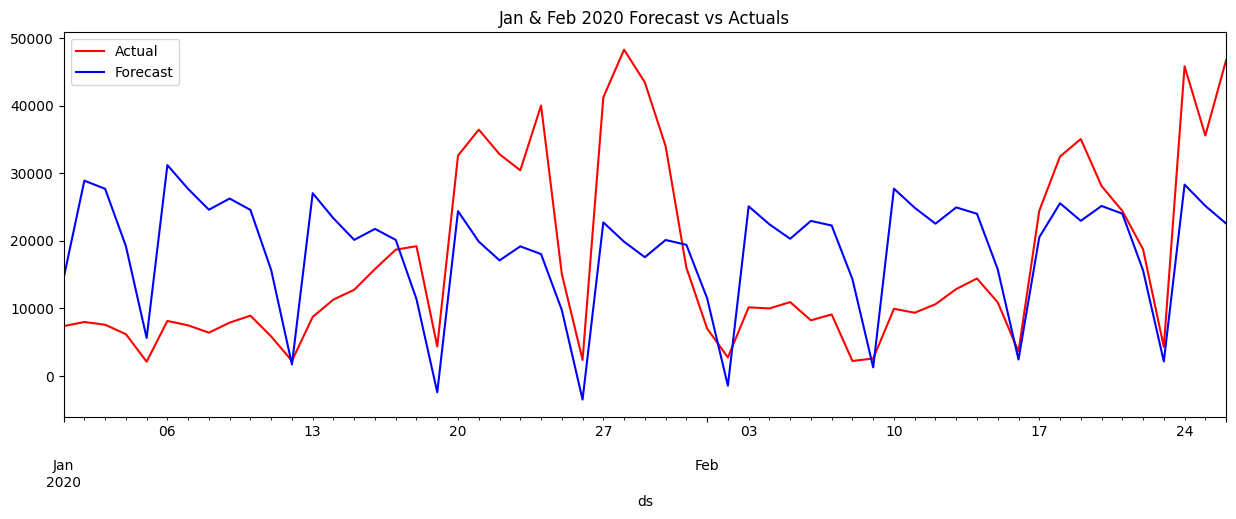

In [89]:
f, ax = plt.subplots(figsize=(14,5))
f.set_figheight(5)
f.set_figwidth(15)
X_tst.plot(kind='line',x='ds', y='y', color='red', label='Actual', ax=ax)
X_tst_final.plot(kind='line',x='ds',y='yhat', color='blue',label='Forecast', ax=ax)
plt.title('Jan & Feb 2020 Forecast vs Actuals')
plt.show()

In [90]:
MAPE = mean_absolute_percentage_error(X_tst['y'],abs(X_tst_final['yhat']))
print('MAPE', MAPE)

MAPE 1.024130797440067


<Axes: >

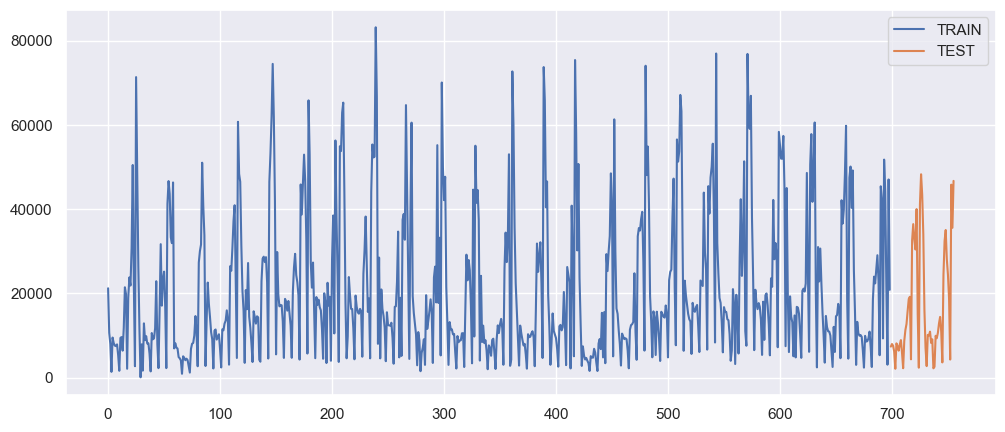

In [113]:
plt.figure(figsize=(12, 5))
X_tr['y'].plot(x='ds', legend=True, label='TRAIN')

X_tst['y'].plot(x='ds', legend=True, label='TEST')

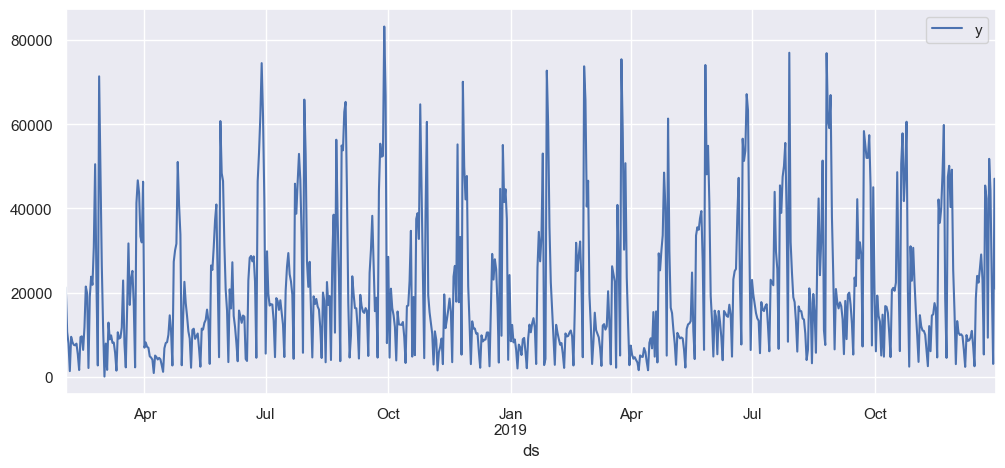

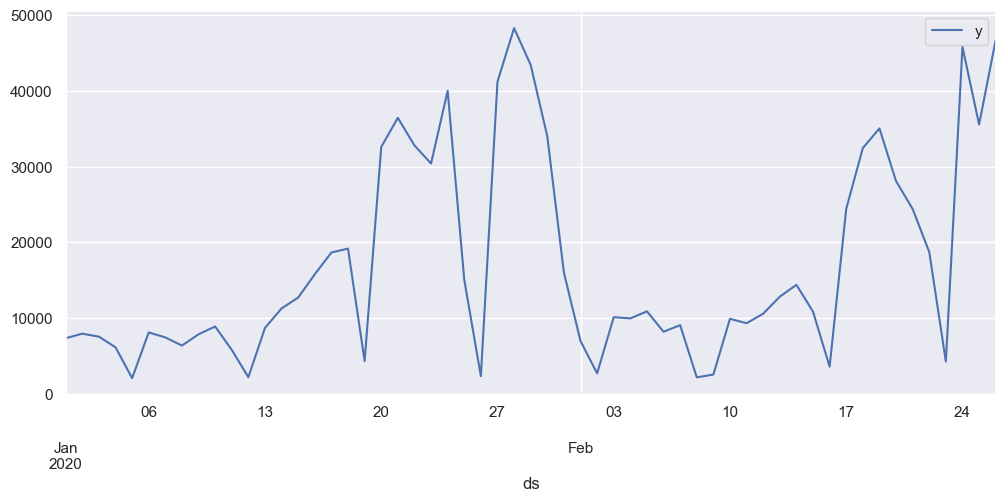

In [115]:
X_tr.set_index('ds').plot(legend=True,figsize=(12, 5),label='TRAIN')
X_tst.set_index('ds').plot(legend=True,figsize=(12, 5),label='TEST')
plt.show()

Pandas' DataFrame plotting has different behavior: each DataFrame .plot() call can create its own Axes/figure rather than reliably reusing the previous one.

In [93]:
forecast

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,Christmas Day,Christmas Day_lower,Christmas Day_upper,Columbus Day,...,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,additive_terms,additive_terms_lower,additive_terms_upper,yhat
0,2018-02-01,76170.442420,-12169.136459,45890.603460,76170.442420,76170.442420,0.0,0.0,0.0,0.0,...,0.050525,0.050525,0.050525,-0.065392,-0.065392,-0.065392,0.0,0.0,0.0,17902.609821
1,2018-02-02,76188.728345,-9257.411549,45229.459920,76188.728345,76188.728345,0.0,0.0,0.0,0.0,...,0.038568,0.038568,0.038568,-0.060792,-0.060792,-0.060792,0.0,0.0,0.0,17346.350295
2,2018-02-03,76207.014271,-16802.084589,37150.292051,76207.014271,76207.014271,0.0,0.0,0.0,0.0,...,-0.054040,-0.054040,-0.054040,-0.056104,-0.056104,-0.056104,0.0,0.0,0.0,10650.413571
3,2018-02-04,76225.300197,-27947.118733,28300.057522,76225.300197,76225.300197,0.0,0.0,0.0,0.0,...,-0.203212,-0.203212,-0.203212,-0.051428,-0.051428,-0.051428,0.0,0.0,0.0,-361.250884
4,2018-02-05,76243.586123,-5158.347386,50585.793978,76243.586123,76243.586123,0.0,0.0,0.0,0.0,...,0.088496,0.088496,0.088496,-0.046855,-0.046855,-0.046855,0.0,0.0,0.0,22228.105739
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
816,2020-04-27,91115.545012,-1448.459437,53621.129674,91115.314876,91115.792374,0.0,0.0,0.0,0.0,...,0.088496,0.088496,0.088496,-0.059880,-0.059880,-0.059880,0.0,0.0,0.0,25377.189626
817,2020-04-28,91133.861053,-4673.825419,49640.860401,91133.626976,91134.112232,0.0,0.0,0.0,0.0,...,0.054131,0.054131,0.054131,-0.055603,-0.055603,-0.055603,0.0,0.0,0.0,22640.247102
818,2020-04-29,91152.177094,-7668.455440,47702.763903,91151.939075,91152.432089,0.0,0.0,0.0,0.0,...,0.025532,0.025532,0.025532,-0.051405,-0.051405,-0.051405,0.0,0.0,0.0,20420.571277
819,2020-04-30,91170.493134,-6174.281723,50592.198711,91170.251184,91170.751925,0.0,0.0,0.0,0.0,...,0.050525,0.050525,0.050525,-0.047327,-0.047327,-0.047327,0.0,0.0,0.0,23075.111764


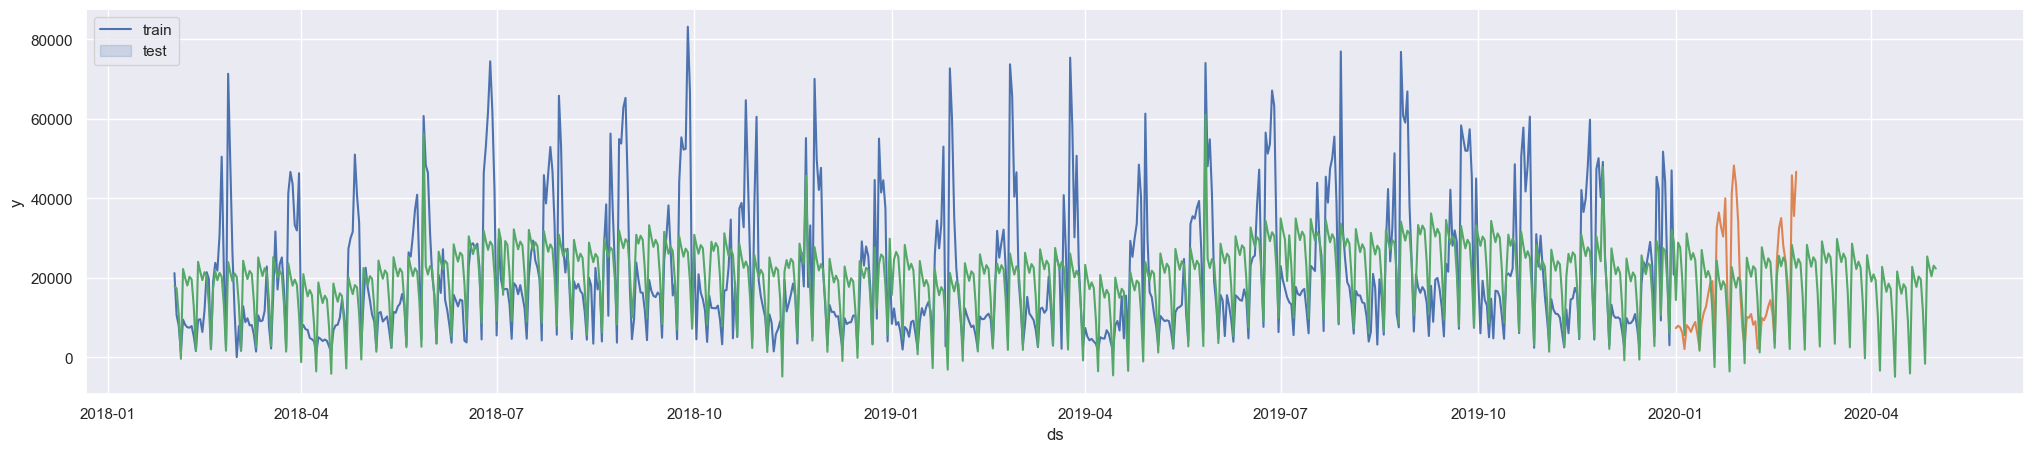

In [122]:
plt.figure(figsize=(25, 5))
sns.lineplot(x=X_tr['ds'], y=X_tr['y'])
sns.lineplot(x=X_tst['ds'], y=X_tst['y'])
sns.lineplot(x=forecast['ds'], y=forecast['yhat'])

plt.legend(['train','test'],
            loc='upper left')
sns.set_theme(rc={'figure.figsize': (8.27, 11.7)})